# Optimizing hyperparameters

In [ ]:
# imports
import mne
import numpy as np
import matplotlib.pyplot as plt
#from sklearn.model_selection import train_test_split, cross_val_score 
import warnings
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score
from toeplitzlda.classification import ToeplitzLDA
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
import numpy as np
from tqdm import tqdm

# utils functions
from utils.preprocessing import all_have_same_condition, list_iterations, load_complete_session, inspect_session, get_n_epochs, get_iteration_structure, get_n_iterations, load_session_chached, merge_sessions, have_same_preprocessing
from utils.feature_extraction import get_jumping_means, epoch_vectorizer_channelprime
from utils.offline_evaluation import compare_auc_single_trial_interval, compute_auc_with_cv
from utils.online_simulation import online_simulation, online_adaptation_simulation_sw

# Turn off warnings (that most likely occur from ToeplitzLDA)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
mne.set_log_level('WARNING')

In [ ]:
all_patient_results = np.load("all_patient_results")

[100, 100, 100, 50, 100, 100, 100, 10, 100, 50, 100, 50, 100, 50, 10, 10, 100, 50, 100, 100, 100, 50, 100, 20, 50, 50, 50, 100, 10, 10, 10, 10, 10, 20, 10, 50, 20, 50, 100, 20]


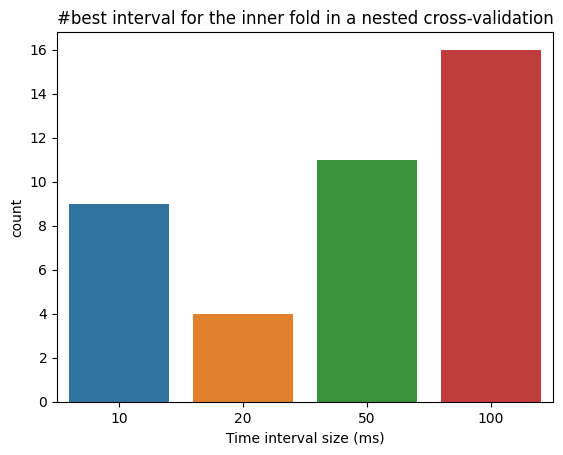

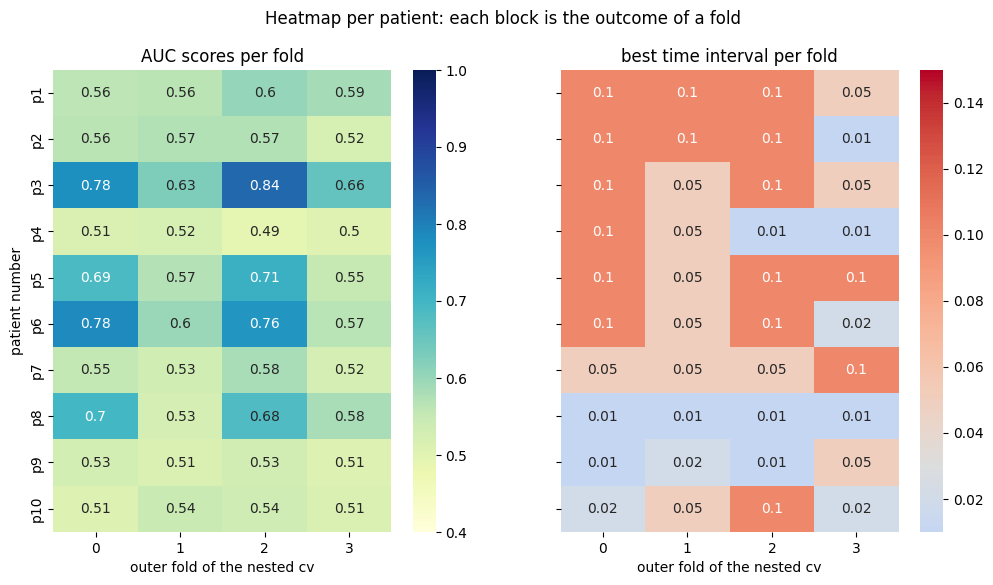

In [ ]:
# Results

import seaborn as sns

# Count plot --------------------------------------

all_folds = []
for patient in all_patient_results.values():
    for fold in patient:
        all_folds.append(int((fold.get('best_ival')[1] - fold.get('best_ival')[0])*1000))

plt.figure()
sns.countplot(all_folds)
plt.title("#best interval for the inner fold in a nested cross-validation")
plt.xlabel("Time interval size (ms)")
plt.show()

# histograms
fig, axs = plt.subplots(1,2, figsize=(12,6),sharey=True)

# Histogram 1 --------------------------------------

all_scores = []
for patient in all_patient_results.keys():
    patient_list = []
    for fold in all_patient_results.get(patient):
        patient_list.append(fold.get('score'))
    all_scores.append(patient_list)

sns.heatmap(all_scores,vmin=0.4,vmax=1,annot=True, yticklabels=['p1','p2','p3','p4','p5','p6','p7','p8','p9','p10'], cmap="YlGnBu", ax=axs[0])
axs[0].set_ylabel("patient number")
axs[0].set_xlabel("outer fold of the nested cv")
axs[0].set_title("AUC scores per fold")

# Histogram 2 --------------------------------------

all_folds_list = []
for patient in all_patient_results.keys():
    fold_list = []
    for fold in all_patient_results.get(patient):
        fold_list.append(((fold.get('best_ival')[1] - fold.get('best_ival')[0])))
    all_folds_list.append(fold_list)

sns.heatmap(all_folds_list,vmin=0.01,vmax=0.15,center=0.03,annot=True,yticklabels=['p1','p2','p3','p4','p5','p6','p7','p8','p9','p10'], cbar=True, cmap="coolwarm", ax=axs[1])
axs[1].set_xlabel("outer fold of the nested cv")
axs[1].set_title("best time interval per fold")
plt.suptitle("Heatmap per patient: each block is the outcome of a fold")
plt.show()

### Time intervals (feature extraction)

#### function

In [ ]:
def nested_cv(trials):
    # Time intervals
    print("Time intervals:")
    ival_bounds_100 = np.arange(0.1,0.51,0.1) # [0.1 0.2 0.3 0.4 0.5] (4)
    print(f"100 ms: \n{ival_bounds_100}")
    ival_bounds_50 = np.arange(0.1,0.51,0.05) # [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5] (8)
    print(f"50 ms: \n{ival_bounds_50}")
    ival_bounds_20 = np.arange(0.1,0.51,0.02) # [0.1  0.12 0.14 ... 0.46 0.48 0.5] (20)
    print(f"20 ms: \n{ival_bounds_20}")
    ival_bounds_10 = np.arange(0.12,0.5,0.01) # [0.12 0.13 0.14 ... 0.48 0.49 0.5] # might be changed
    print(f"10 ms: \n{ival_bounds_10}")

    # Nested cv settings
    ival_grid = [
                ival_bounds_100, 
                ival_bounds_50, 
                ival_bounds_20, 
                ival_bounds_10
                ]
    n_trials = len(trials)
    K_outer_folds = 4
    K_inner_folds = 3
    outer_fold_size = int(n_trials/K_outer_folds)

    print(f"\nn_trials: {len(trials)}")
    print(f"With a outer {K_outer_folds}-fold cross-vaidation:")
    print(f"There are {K_outer_folds} outer folds with each outer_fold_size: {outer_fold_size}")
    print(f"\tIn each outer fold, we have an inner {K_inner_folds}-fold cross-vaidation:")
    print(f"\t\tEach inner fold has inner_fold_size: {int(outer_fold_size/K_inner_folds)}")

    print("\nPerforming cross-validation...")

    outer_kf = KFold(n_splits=K_outer_folds, shuffle=False)
    outer_scores = []
    nch = (trials[0][0]).info["nchan"]


    # outer cv
    outer_results = [] # store (score, best_ival) for each outer fold

    for outer_fold_idx, (outer_train_idx, outer_test_idx) in enumerate(tqdm(outer_kf.split(trials), total=K_outer_folds, desc="Outer CV")):
    #for outer_train_idx, outer_test_idx in outer_kf.split(trials):
        print(f"\nOuter fold {outer_fold_idx + 1}/{K_outer_folds}")

        outer_train = [trials[i] for i in outer_train_idx]  # | |x|x|x| for fold 1, |x| |x|x| for fold 2, ...
        outer_test = [trials[i] for i in outer_test_idx]    # |x| | | | for fold 1, | |x| | | for fold 2, ...

        # Loop over all time interval options
        best_ival = None
        best_score = -np.inf

        for ival_idx, ival in enumerate(tqdm(ival_grid, desc="Testing intervals", leave=False)):
        #for ival in ival_grid:
            inner_kf = KFold(n_splits=K_inner_folds, shuffle=False)
            inner_scores = []

            # inner cv
            for inner_train_idx, inner_val_idx in inner_kf.split(outer_train):
                inner_train = [outer_train[i] for i in inner_train_idx] 
                inner_val = [outer_train[i] for i in inner_val_idx]

                # feature extraction
                X_train,y_train = epoch_vectorizer_channelprime(inner_train,ival)
                X_val,y_val = epoch_vectorizer_channelprime(inner_val,ival)

                # classifier
                clf_btlda = make_pipeline(
                    ToeplitzLDA(n_channels=nch),
                )
                clf_btlda.fit(X_train,y_train)

                # clf = LinearDiscriminantAnalysis()
                # clf.fit(X_feat_train, y_inner_train)
                y_scores = clf_btlda.decision_function(X_val)
                score = roc_auc_score(y_val, y_scores) # this inner fold's AUC score
                inner_scores.append(score)

            # average after inner cv
            avg_inner_score = np.mean(inner_scores)
            # save best time ival so far
            if avg_inner_score > best_score:
                best_score = avg_inner_score
                best_ival = ival

        # OUTER TEST using best ival
        X_train_complete, y_train_complete = epoch_vectorizer_channelprime(outer_train,best_ival)
        X_test_complete, y_test_complete = epoch_vectorizer_channelprime(outer_test, best_ival)

        # classifier
        clf_btlda_final = make_pipeline(
            ToeplitzLDA(n_channels=nch),
        )
        clf_btlda_final.fit(X_train_complete,y_train_complete)
        y_scores_test = clf_btlda_final.decision_function(X_test_complete)

        outer_score = roc_auc_score(y_test_complete, y_scores_test)
        outer_scores.append(outer_score)
        outer_results.append({"score": outer_score, "best_ival": best_ival})
        print(f"Outer fold AUC: {outer_score:.4f} (Best ival: {best_ival})")

    print(f"\nAverage AUC over {K_outer_folds} folds: {np.mean(outer_scores):.4f}")
    
    return outer_results



#### Run procedure (very long)

In [ ]:
# runtime: 78 min
# Procedure: nested cross-validation for all patients

all_patient_results = dict() # storing p1:      [fold 1: (auc, best_ival), 
                             #                   fold 2: (auc, best_ival),
                             #                   fold 3: (auc, best_ival),
                             #                   fold 4: (auc, best_ival)]
                             # p2:              [ ... ]

for i in range(1,11): # i = 1, 2, ..., 10
    # load data
    data_s1 = load_session_chached(f"data_p{i}/P{i}_S1/anonymized", 
                               #selection = "6D_long_350", 
                               discard_channels=True)
    data_s2 = load_session_chached(f"data_p{i}/P{i}_S2/anonymized", 
                                #selection = "6D_long_350", 
                                discard_channels=True)
    data_s12 = merge_sessions(data_s1, data_s2)
    trials = data_s12.get('trials')

    # perform nested cv
    outer_results = nested_cv(trials)

    # store results
    all_patient_results[f'P{i}'] = outer_results

Loading file:  data_p1_P1_S1_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S1_anonymized_dc.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S1_anonymized_dc.pkl
Loading file:  data_p1_P1_S2_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S2_anonymized_dc.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S2_anonymized_dc.pkl
Time intervals:
100 ms: 
[0.1 0.2 0.3 0.4 0.5]
50 ms: 
[0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5 ]
20 ms: 
[0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26 0.28 0.3  0.32 0.34 0.36
 0.38 0.4  0.42 0.44 0.46 0.48 0.5 ]
10 ms: 
[0.12 0.13 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25
 0.26 0.27 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39
 0.4  0.41 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49]

n_trials: 120
With a outer 4-fold cross-vaidation:
There are 4 outer folds with each outer_fold_size: 30
	In each outer fold, we have an inner 3-fold cross-vaidation:
		Each inner fold has inner_

Outer CV:   0%|          | 0/4 [00:00<?, ?it/s]


Outer fold 1/4


Outer CV:  25%|██▌       | 1/4 [01:06<03:18, 66.19s/it]

Outer fold AUC: 0.5604 (Best ival: [0.1 0.2 0.3 0.4 0.5])

Outer fold 2/4


...

Outer fold AUC: 0.5450 (Best ival: [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5 ])

Outer fold 3/4


Outer CV:  75%|███████▌  | 3/4 [03:09<01:02, 62.57s/it]

Outer fold AUC: 0.5366 (Best ival: [0.1 0.2 0.3 0.4 0.5])

Outer fold 4/4


Outer CV: 100%|██████████| 4/4 [04:16<00:00, 64.02s/it]

Outer fold AUC: 0.5138 (Best ival: [0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26 0.28 0.3  0.32 0.34 0.36
 0.38 0.4  0.42 0.44 0.46 0.48 0.5 ])

Average AUC over 4 folds: 0.5262


In [32]:
inspect_session("data_p3/P3_S1/anonymized")

Condition per run: 
['6D', '6D', '6D', '6D', '6D', '6D', 'HP', 'HP', 'HP', 'HP', 'HP', 'HP']
['long', 'long', 'long', 'short', 'short', 'short', 'long', 'long', 'long', 'short', 'short', 'short']
All conditions of this session are the same:  False
Number of iterations per trial:
Run 0: [15 15 15 15 15 15]
Run 1: [15 15 15 15 15 15]
Run 2: [15 15 15 15 15 15]
Run 3: [15 15 15 15 15 15]
Run 4: [15 15 15 15 15 15]
Run 5: [15 15 15 15 15 15]
Run 6: [15 15 15 15 15 15]
Run 7: [15 15 15 15 15 15]
Run 8: [15 15 15 15 15 15]
Run 9: [15 15 15 15 15 15]
Run 10: [15 15 15 15 15 15]
Run 11: [15 15 15 15 15 15]


In [13]:
print("PATIENT 2")
for filename in data_s12.get('filenames'):
    print(filename)
print(f"\nAverage AUC over {K_outer_folds} folds: {np.mean(outer_scores):.4f}")

for i, result in enumerate(outer_results):
    print(f"Fold {i+1}: AUC={result['score']:.4f}, Best ival={result['best_ival']}")

PATIENT 2
P2_S1/anonymized/auditoryAphasia_6D_long_350_Block1_Run1.vhdr
P2_S1/anonymized/auditoryAphasia_6D_long_350_Block2_Run1.vhdr
P2_S1/anonymized/auditoryAphasia_6D_long_350_Block3_Run1.vhdr
P2_S1/anonymized/auditoryAphasia_6D_short_250_Block1_Run4.vhdr
P2_S1/anonymized/auditoryAphasia_6D_short_250_Block2_Run3.vhdr
P2_S1/anonymized/auditoryAphasia_6D_short_250_Block3_Run3.vhdr
P2_S1/anonymized/auditoryAphasia_HP_long_350_Block1_Run2.vhdr
P2_S1/anonymized/auditoryAphasia_HP_long_350_Block2_Run2.vhdr
P2_S1/anonymized/auditoryAphasia_HP_long_350_Block3_Run2.vhdr
P2_S1/anonymized/auditoryAphasia_HP_short_250_Block1_Run5.vhdr
P2_S1/anonymized/auditoryAphasia_HP_short_250_Block2_Run4.vhdr
P2_S1/anonymized/auditoryAphasia_HP_short_250_Block3_Run4.vhdr
P2_S2/anonymized/auditoryAphasia_6D_long_350_Block1_Run1.vhdr
P2_S2/anonymized/auditoryAphasia_6D_long_350_Block2_Run1.vhdr
P2_S2/anonymized/auditoryAphasia_6D_long_350_Block3_Run1.vhdr
P2_S2/anonymized/auditoryAphasia_6D_long_350_Block4_Ru